# Technology for Energy systems integration - Final Assignment
## Energy transition study with integration of multiple energy carriers

POINT 1: Design of renewable production, electricity transmission and storage for given demand and constraints

In [589]:
from math import nan

import pandas as pd
import numpy as np
import requests
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pvlib
import matplotlib


In [590]:
# Given information:
node_lat = 54.6172
node_lon = 9.5776
node_alt = 0

distance12 = 53 #km

electricity_demand_multiplier = 0.54
heat_demand_multiplier = 0.43

In [591]:
# Create time series with hourly resolution for the given period
year = 2009
month = 2
times = pd.date_range(start='2009-02-01', end='2009-02-28 23:59:59', freq='h', tz='Europe/Amsterdam')

In [592]:
# Function to import climate data from JRC - DO NOT CHANGE

def import_jrc_climate_data(lon: float, lat: float, year: int | str, alt: float) -> dict:
    """
    Reads in climate data for a full year from `JRC PVGIS <https://re.jrc.ec.europa.eu/pvg_tools/en/>`_.

    :param float lon: longitude of node - the api will read data for this location
    :param float lat: latitude of node - the api will read data for this location
    :param int year: optional, needs to be in range of data available. If nothing is specified, a typical year \
    will be loaded
    :param float alt: altitude of location specified
    :return: dict containing information on the location (altitude, longitude, latitude and a dataframe \
    containing climate data (ghi = global horizontal irradiance, dni = direct normal irradiance, \
    dhi = diffuse horizontal irradiance, rh = relative humidity, temp_air = air temperature, ws = wind speed at \
    specified hight. Wind speed is returned as a dict for different heights.
    :rtype: dict
    """

    # Specify year import, lon, lat
    parameters = {"lon": lon, "lat": lat, "year": year, "outputformat": "json"}
    time_index = pd.date_range(
        start=str(year) + "-01-01 00:00", end=str(year) + "-12-31 23:00", freq="1h"
    )

    # Get data from JRC dataset
    answer = dict()
    print("Importing Climate Data...")
    response = requests.get("https://re.jrc.ec.europa.eu/api/tmy?", params=parameters)
    if response.status_code == 200:
        print("Importing Climate Data successful")
    else:
        raise Exception(response)
    data = response.json()
    climate_data = data["outputs"]["tmy_hourly"]

    # Compile return dict
    answer["longitude"] = lon
    answer["latitude"] = lat
    answer["altitude"] = alt

    ghi = []
    dni = []
    dhi = []
    rh = []
    temp_air = []
    wind_speed = dict()
    wind_speed["10"] = []

    for t_interval in climate_data:
        ghi.append(t_interval["G(h)"])
        dni.append(t_interval["Gb(n)"])
        dhi.append(t_interval["Gd(h)"])
        rh.append(t_interval["RH"])
        temp_air.append(t_interval["T2m"])
        wind_speed["10"].append(t_interval["WS10m"])

    answer["dataframe"] = pd.DataFrame(
        np.array([ghi, dni, dhi, temp_air, rh]).T,
        columns=["ghi", "dni", "dhi", "temp_air", "rh"],
        index=time_index,
    )
    for ws in wind_speed:
        answer["dataframe"]["ws" + str(ws)] = wind_speed[ws]

    return answer

In [593]:
# Import climate data

climate_data = import_jrc_climate_data(node_lon, node_lat, year, node_alt)

Importing Climate Data...
Importing Climate Data successful


In [594]:
# Create wind turbine power curve function - DO NOT CHANGE
name = "WindTurbine_Onshore_4000"
wt_data_path = 'data/WT_data.csv'
wt_data_full = pd.read_csv(wt_data_path, delimiter=";")
# match WT with data
wt_data = wt_data_full[wt_data_full["TurbineName"] == name]
hubheight = 120

# Make power curve
rated_capacity = wt_data.iloc[0]["RatedPowerkW"]
wind_speed = np.linspace(0, 35, 71)
power_output = wt_data.iloc[:, 13:84]
power_output = power_output.to_numpy()

f = interp1d(wind_speed, power_output)

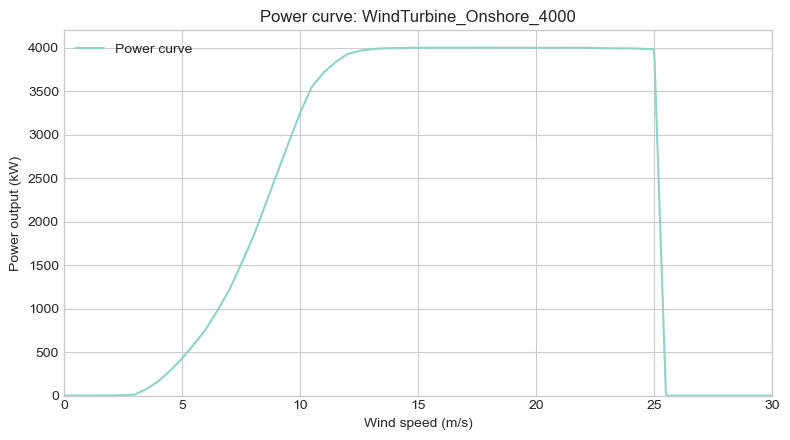

In [595]:
# Vizualize power curve

x_plot = np.linspace(0, 30, 1000)
y_plot = f(x_plot).ravel()

plt.figure(figsize=(8, 4.5))
plt.plot(x_plot, y_plot, label="Power curve")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power output (kW)")
plt.title(f"Power curve: {name}")
plt.legend()
plt.grid(True)
plt.xlim(0, 30)
plt.ylim(0, max(float(rated_capacity) * 1.05, power_output.max() * 1.05))
plt.tight_layout()
plt.show()

In [596]:
# Weather data - DO NOT CHANGE
df = climate_data['dataframe']

if "ws100" in df.columns:
    ws = df["ws100"]
    ws_height = 100
else:
    ws = df["ws10"]
    ws_height = 10

alpha = 1/7

if hubheight > 0:
    ws = ws * (hubheight / ws_height) ** alpha

In [597]:
# defining pv data - DO NOT CHANGE

pv_system_data = dict()
pv_system_data["tilt"] = 18
pv_system_data["surface_azimuth"] = 180
pv_system_data["module_name"] = "SunPower_SPR_X20_327"
pv_system_data["inverter_eff"] = 0.96

inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

In [598]:
# Fitting pv system - DO NOT CHANGE
module_database = pvlib.pvsystem.retrieve_sam("CECMod")
module = module_database[pv_system_data["module_name"]]

temperature_model_parameters = (
    pvlib.temperature.TEMPERATURE_MODEL_PARAMETERS["sapm"][
        "open_rack_glass_glass"
    ]
)

# Create PV model chain
inverter_parameters = {
    "pdc0": 5000,
    "eta_inv_nom": pv_system_data["inverter_eff"],
}

system = pvlib.pvsystem.PVSystem(
    surface_tilt=pv_system_data["tilt"],
    surface_azimuth=pv_system_data["surface_azimuth"],
    module_parameters=module,
    inverter_parameters=inverter_parameters,
    temperature_model_parameters=temperature_model_parameters,
)

# Get location
tz = 'Europe/Amsterdam'

location = pvlib.location.Location(node_lat, node_lon, tz=tz, altitude=node_alt)

pv_model = pvlib.modelchain.ModelChain(
    system, location, spectral_model="no_loss", aoi_model="physical"
)
peakpower = module.STC

In [599]:
# Electricity and Heat demand data
import calendar

skip = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

demand_data_path = 'data/demand_production.xlsx'
df_p1 = pd.read_excel(demand_data_path, sheet_name='Point1', header=1)

el_demand   = df_p1['Electricity [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
el_demand   = el_demand.set_axis(times)
el_demand   = el_demand * electricity_demand_multiplier * 1000 # kWh

heat_demand = df_p1['Heat [MWh]'].iloc[skip : skip + len(times)].reset_index(drop=True)
heat_demand = heat_demand.set_axis(times)
heat_demand = heat_demand * heat_demand_multiplier * 1000 # kWh

# print(f"Total electricity demand: {el_demand.sum():.1f} MWh")
# print(f"Average hourly demand: {el_demand.mean():.1f} MW")
# print(f"Peak demand: {el_demand.max():.1f} MW")
# print(f"Hours in dataset: {len(el_demand)}")  # should be 672 for February 2009

In [600]:
# Energy production

# Hours to skip to reach the selected month
skip_hours = sum(calendar.monthrange(year, m)[1] for m in range(1, month)) * 24

# wind capacity factor
capacity_factor_wind = f(np.clip(ws.values, 0, 35)) / 4000
capacity_factor_wind = pd.Series(
    np.asarray(capacity_factor_wind).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)

# solar capacity factor
pv_model.run_model(df)
power = pv_model.results.ac.p_mp
capacity_factor_solar = power / peakpower

capacity_factor_solar = pd.Series(
    np.asarray(capacity_factor_solar).flatten()[skip_hours:skip_hours + len(times)],
    index=times
)
print(capacity_factor_wind)

C:\Users\Stefv\anaconda3\envs\pypsa_esi\Lib\site-packages\scipy\optimize\_chandrupatla.py:437: RuntimeWarning:

invalid value encountered in divide



2009-02-01 00:00:00+01:00    0.286289
2009-02-01 01:00:00+01:00    0.222288
2009-02-01 02:00:00+01:00    0.166264
2009-02-01 03:00:00+01:00    0.120219
2009-02-01 04:00:00+01:00    0.079696
                               ...   
2009-02-28 19:00:00+01:00    0.014010
2009-02-28 20:00:00+01:00    0.012189
2009-02-28 21:00:00+01:00    0.009913
2009-02-28 22:00:00+01:00    0.008092
2009-02-28 23:00:00+01:00    0.006272
Freq: h, Length: 672, dtype: float64


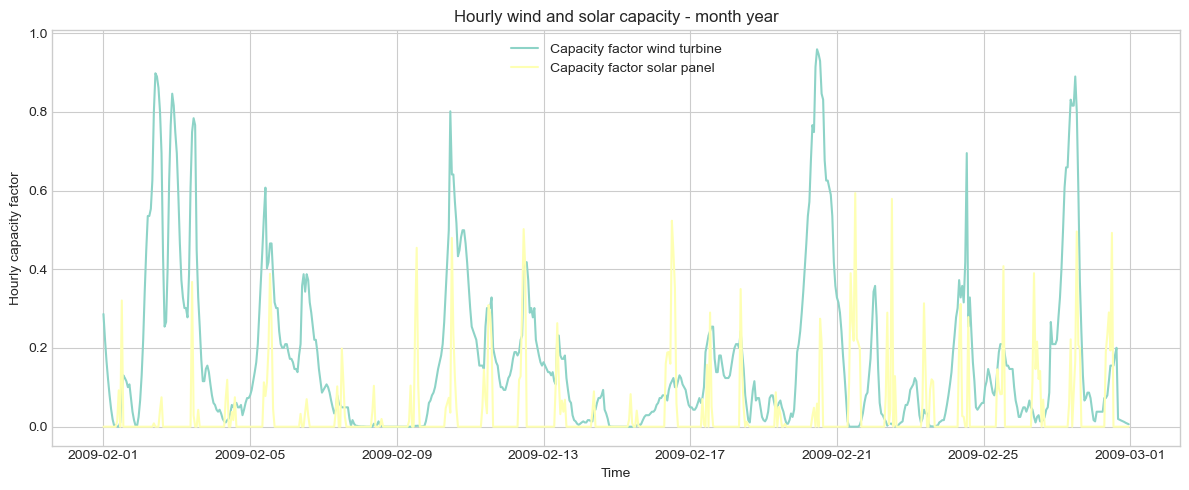

In [601]:
# Plot of capacity factors

plt.figure(figsize=(12, 5))

plt.plot(capacity_factor_wind.index, capacity_factor_wind, label='Capacity factor wind turbine')
plt.plot(capacity_factor_solar.index, capacity_factor_solar, label='Capacity factor solar panel')

plt.xlabel('Time')
plt.ylabel('Hourly capacity factor')
plt.title('Hourly wind and solar capacity - month year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [602]:
# Obtaining techno-economic data

tech_eco_data_path = 'data/technoeconomic_data.xlsx'
tech_eco_data = pd.read_excel(tech_eco_data_path, sheet_name='Data', header=2)

def get_value(df, component, data_type):
    mask = (df['component'] == component) & (df['parameter'] == data_type)
    result = df.loc[mask, 'value']
    if len(result) == 0:
        raise ValueError(f"No data found for component='{component}', parameter='{data_type}'")
    return result.values[0]

# We give you the wind turbine techno-economic data import as example. Save all the relevant data with the same function
# !!Make sure to use the correct units!!

# Wind turbine
Wind_capex = get_value(tech_eco_data, 'Wind turbine', 'Investment cost')  # EUR/kW
Wind_lifetime = get_value(tech_eco_data, 'Wind turbine', 'Lifetime')  # year
Wind_opex = get_value(tech_eco_data, 'Wind turbine', 'Opex') / 100  # % capex/year

In [603]:
# grab additional techno-economic data
Solar_capex = get_value(tech_eco_data, 'Solar panel', 'Investment cost')  #EUR/kw
Solar_lifetime = get_value(tech_eco_data, 'Solar panel', 'Lifetime') # year
Solar_opex = get_value(tech_eco_data, 'Solar panel', 'Opex') / 100 # % capex/year math included
Electricity_cable_capex = get_value(tech_eco_data, 'Electricity cable', 'Investment cost') #EUR/kw/km
Electricity_cable_lifetime = get_value(tech_eco_data, 'Electricity cable', 'Lifetime') # year
Electricity_cable_fixed_opex = get_value(tech_eco_data, 'Electricity cable', 'Fixed Opex') / 100 # %capex/year
Electricity_cable_losses = get_value(tech_eco_data, 'Electricity cable', 'Losses') / 100 # % per 100km

# relevant for part 2
# Hydrogen_pipeline_capex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Investment cost') # Eur/kw/km
# Hydrogen_pipeline_lifetime = get_value(tech_eco_data, 'Hydrogen pipeline', 'Lifetime') # year
# Hydrogen_pipeline_fixed_opex = get_value(tech_eco_data, 'Hydrogen pipeline', 'Fixed Opex') /100 # % capex/year
# Hydrogen_pipeline_losses = get_value(tech_eco_data, 'Hydrogen pipeline', 'Losses') /100 # % per 100km

Li_ion_battery_capex = get_value(tech_eco_data, 'Li-ion battery', 'Investment cost') # EUR/kWh
Li_ion_battery_lifetime = get_value(tech_eco_data, 'Li-ion battery', 'Lifetime') # year
Li_ion_battery_opex = get_value(tech_eco_data, 'Li-ion battery', 'Opex') / 100 # % capex/year
Li_ion_battery_charging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Charging efficiency') / 100 # % input energy
Li_ion_battery_discharging_efficiency = get_value(tech_eco_data, 'Li-ion battery', 'Discharging efficiency') / 100 # % output energy
Li_ion_battery_self_discharge_coefficient = get_value(tech_eco_data, 'Li-ion battery', 'Self-discharge coefficient') / 100 # % per hour
Li_ion_battery_max_charging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max charging capacity') / 100 # % size of battery
Li_ion_battery_max_discharging_capacity = get_value(tech_eco_data, 'Li-ion battery', 'Max discharging capacity') / 100 # % size of battery

# relevant for part 2
# Hydrogen_storage_tank_capex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Investment cost') # EUR/kWh
# Hydrogen_storage_tank_lifetime = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Lifetime') #year
# Hydrogen_storage_tank_opex = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Opex') / 100 # % capex/year
# Hydrogen_storage_tank_charging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Charging efficiency') / 100 # % input energy
# Hydrogen_storage_tank_discharging_efficiency = get_value(tech_eco_data, 'Hydrogen storage - tank','Discharging efficiency') # error in data this does not need division by 100 % output energy
# Hydrogen_storage_tank_self_discharge_coefficient = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Self-discharge coefficient') / 100# %/hour
# Hydrogen_storage_tank_max_charging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max charging capacity') / 100 # %/size
# Hydrogen_storage_tank_max_discharging_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max discharging capacity') / 100 # %/size
# Hydrogen_storage_tank_max_capacity = get_value(tech_eco_data, 'Hydrogen storage - tank', 'Max capacity') # MWh
#
# Heat_storage_high_temp_capex = get_value(tech_eco_data, 'Heat storage - High temp', 'Investment cost') # EUR/MWh
# Heat_storage_high_temp_lifetime = get_value(tech_eco_data, 'Heat storage - High temp', 'Lifetime') # year
# Heat_storage_high_temp_opex = get_value(tech_eco_data, 'Heat storage - High temp', 'Opex') / 100 # % capex/year
# Heat_storage_high_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp', 'Charging efficiency') / 100 # % input energy
# Heat_storage_high_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - High temp','Discharging efficiency') / 100 # % output energy
# Heat_storage_high_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - High temp', 'Self-discharge coefficient') # % / hour
# Heat_storage_high_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max charging capacity') / 100 # % size
# Heat_storage_high_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - High temp', 'Max discharging capacity') / 100 # % size
#
# Heat_storage_low_temp_capex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Investment cost') # EUR/MWh
# Heat_storage_low_temp_lifetime = get_value(tech_eco_data, 'Heat storage - Low temp', 'Lifetime') # year
# Heat_storage_low_temp_opex = get_value(tech_eco_data, 'Heat storage - Low temp', 'Opex') /100 # % capex/year
# Heat_storage_low_temp_charging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp', 'Charging efficiency') / 100 # % input energy
# Heat_storage_low_temp_discharging_efficiency = get_value(tech_eco_data, 'Heat storage - Low temp','Discharging efficiency') / 100# % output energy
# Heat_storage_low_temp_self_discharge_coefficient = get_value(tech_eco_data, 'Heat storage - Low temp', 'Self-discharge coefficient') / 100 # % / hour
# Heat_storage_low_temp_max_charging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max charging capacity') / 100 # % size
# Heat_storage_low_temp_max_discharging_capacity = get_value(tech_eco_data, 'Heat storage - Low temp', 'Max discharging capacity') / 100 # % size
#
# Heat_pump_coefficient_of_performance = get_value(tech_eco_data, 'Heat pump', 'COP') # no unit
# Hydrogen_boiler_efficiency = get_value(tech_eco_data, 'Hydrogen boiler', 'Efficiency') / 100 # % input energy
Operational_cost_lost_load_penalty = get_value(tech_eco_data, 'Operational cost', 'Lost load penalty') # EUR/MWh
Operational_cost_max_import_availability = get_value(tech_eco_data, 'Operational cost', 'Max import availability') # MWh
Operational_cost_electricity_import_cost = get_value(tech_eco_data, 'Operational cost', 'Electricity import cost') # EUR/MWh
# Operational_cost_hydrogen_market_price = get_value(tech_eco_data, 'Operational cost', 'Hydrogen market price') # EUR/MWh


## CHOICES TO MAKE BELOW

In [604]:
#Stocks
Solar_capacity = 5500             # kW  # 50000
Wind_capacity = 58150              # kW  # 50000
Battery_zone1_capacity = 00000     # kWh; must be one or the other # 00000
Battery_zone2_capacity = 00000     # kWh; must be one or the other # 25000
Cables_capacity = 30000            # kW; must be in increments of 10,000 kW # 30000

#Generation, demand, import and shortages
Wind_generation = Wind_capacity * capacity_factor_wind    # kWh
Solar_generation = Solar_capacity * capacity_factor_solar # kWh
Total_RES_generation = Wind_generation + Solar_generation # kWh

# el_demand = el_demand * 1000                          # kWh; multiplying by 1000 because previously in MWh
# heat_demand = heat_demand * 1000                      # kWh

Residual_load = pd.Series(0.0, index=times)         # kWh
Electricity_import = pd.Series(0.0, index=times)    # kWh; Electricity that must be imported
Electricity_shortage = pd.Series(0.0, index=times)  # kWh; Electricity shortage
Overshoot_load = pd.Series(0.0, index=times)     # kWh

#Battery generic
ETA_charge = Li_ion_battery_charging_efficiency             # eta is efficiency
ETA_discharge = Li_ion_battery_discharging_efficiency       # eta is efficiency
Self_discharge = Li_ion_battery_self_discharge_coefficient  # % per hour               # kW

#Battery zone 1
Battery_zone1_max_charge = (Li_ion_battery_max_charging_capacity) * Battery_zone1_capacity        # kW
Battery_zone1_max_discharge = (Li_ion_battery_max_discharging_capacity) * Battery_zone1_capacity  # kW
SOC_zone1 = pd.Series(0.0, index=times)          # State of charge
Charge_zone1 = pd.Series(0.0, index=times)       # Charging power
Discharge_zone1 = pd.Series(0.0, index=times)    # Discharging power
Leftover_load_zone1 = pd.Series(0.0, index=times)

#Battery zone 2
Battery_zone2_max_charge = (Li_ion_battery_max_charging_capacity) * Battery_zone2_capacity        # kW
Battery_zone2_max_discharge = (Li_ion_battery_max_discharging_capacity) * Battery_zone2_capacity  # kW
SOC_zone2 = pd.Series(0.0, index=times)          # State of charge
Charge_zone2 = pd.Series(0.0, index=times)       # Charging power
Discharge_zone2 = pd.Series(0.0, index=times)    # Discharging power
Leftover_load_zone2 = pd.Series(0.0, index=times)

#Generic set-up
hours = len(times)

In [605]:
# --- Loop over hours ---
for i, t in enumerate(times):
    Residual_load[t] = (Total_RES_generation[t] * (1 - (Electricity_cable_losses * (distance12 / 100)))) - el_demand[t] # at zone 2 if not limited by cables
    Leftover_load_zone1[t] = Total_RES_generation[t] - min(el_demand[t] / (1 - (Electricity_cable_losses * (distance12 / 100))), Cables_capacity)
    Leftover_load_zone2[t] = min(Total_RES_generation[t] * (1 - (Electricity_cable_losses * (distance12 / 100))), Cables_capacity) - el_demand[t]

    # Leftover_load_zone1[t] = (el_demand[t] / (1 - (Electricity_cable_losses) * (distance12 / 100))) - min(0, Cables_capacity - Total_RES_generation[t])
    #                           # use if RES is larger than cable capacity and so a battery at zone 1 can be charged more. This might not be working correctly, so I took it out. Change 'Residual_load' in battery for zone 1 (below) to 'Leftover_load_zone1' if we want to implement again. Right now, if the cables are "full", the leftover power at zone 1 is wasted if its battery is full too.
    # Leftover_load_zone2[t] = min(0, Cables_capacity, (Residual_load[t] / (1 - (Electricity_cable_losses) * (distance12 / 100))))

    Prev_SOC_zone1 = SOC_zone1.iloc[i-1] if i > 0 else (Battery_zone1_capacity/2)  # previous hour SOC for zone 1
    Prev_SOC_zone2 = SOC_zone2.iloc[i-1] if i > 0 else (Battery_zone2_capacity/2)  # previous hour SOC for zone 2

#Battery at zone 1
    if Leftover_load_zone1[t] > 0:  # surplus → charge battery
        Charge_power_zone1 = min(Leftover_load_zone1[t], Battery_zone1_max_charge, Battery_zone1_capacity - Prev_SOC_zone1)
        Charge_zone1[t] = Charge_power_zone1 * ETA_charge
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Self_discharge) + Charge_zone1[t]

    elif Leftover_load_zone1[t] < 0:  # deficit → discharge battery
        Discharge_power_zone1 = min(-Leftover_load_zone1[t], Battery_zone1_max_discharge, Prev_SOC_zone1)
        Discharge_zone1[t] = Discharge_power_zone1 * ETA_discharge
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Self_discharge) - Discharge_zone1[t] / ETA_discharge

    else:  # no surplus or deficit
        SOC_zone1[t] = Prev_SOC_zone1 * (1 - Self_discharge)

#Battery at zone 2
    if Leftover_load_zone2[t] > 0:
        Charge_power_zone2 = min(Leftover_load_zone2[t], Battery_zone2_max_charge, Battery_zone2_capacity - Prev_SOC_zone2)
        Charge_zone2[t] = Charge_power_zone2 * ETA_charge
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Self_discharge) + Charge_zone2[t]

    elif Leftover_load_zone2[t] < 0:  # deficit → discharge battery
        Discharge_power_zone2 = min(-Leftover_load_zone2[t], Battery_zone2_max_discharge, Prev_SOC_zone2)
        Discharge_zone2[t] = Discharge_power_zone2 * ETA_discharge
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Self_discharge) - Discharge_zone2[t] / ETA_discharge

    else:  # no surplus or deficit
        SOC_zone2[t] = Prev_SOC_zone2 * (1 - Self_discharge)

    # Update residual load after battery action

    if Residual_load[t] < 0:
        Residual_load[t] = Residual_load[t] + (min((Cables_capacity - Total_RES_generation[t]), Discharge_zone1[t]) * ((1 - Electricity_cable_losses) * (distance12 / 100))) + Discharge_zone2[t]
    elif Residual_load[t] > 0:
        Overshoot_load[t] = (Residual_load[t] - (Charge_zone1[t] * ((1 - Electricity_cable_losses) * (distance12 / 100))) - (min(((Cables_capacity - Total_RES_generation[t]) * ((1 - Electricity_cable_losses) * (distance12 / 100))), Charge_zone2[t]))) / ((1 - Electricity_cable_losses) * (distance12 / 100))
    else:
        Residual_load[t] = 0

    # Residual_load[t] = Residual_load[t] + Charge_zone1[t] - Discharge_zone1[t] + Charge_zone2[t] - Discharge_zone2[t]

    if Residual_load[t] < 0:
        Electricity_import[t] = min(-Residual_load[t], Operational_cost_max_import_availability * 1000)
        Residual_load[t] = Residual_load[t] + Electricity_import[t]

    else:
        Electricity_import[t] = 0

    if Residual_load[t] < 0:
        Electricity_shortage[t] = -Residual_load[t]

    else:
        Electricity_shortage[t] = 0

In [606]:
#Interest rate
Interest_rate = 0.05 # % / year
Interest_rate_monthly = ((1 + Interest_rate)**(1 / 12)) - 1 # % / month

#Solar
Solar_capex_cost = Solar_capacity * Solar_capex # EUR
Solar_opex_cost = Solar_capex_cost * Solar_opex # EUR / year
Solar_lifetime_months = Solar_lifetime * 12 # month
Solar_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Solar_lifetime_months)) # No unit
Solar_total_capex_cost_monthly = Solar_capex_cost * Solar_capital_recovery_factor_monthly # EUR / month; '+ Solar_capex_cost' if we assume we pay for OCC in one go
Solar_total_opex_cost_monthly = (Solar_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Solar_total_cost_monthly = Solar_total_capex_cost_monthly + Solar_total_opex_cost_monthly # EUR / month

#Wind
Wind_capex_cost = Wind_capacity * Wind_capex # EUR
Wind_opex_cost = Wind_capex_cost * Wind_opex # EUR / year
Wind_lifetime_months = Wind_lifetime * 12 # month
Wind_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Wind_lifetime_months)) # No unit
Wind_total_capex_cost_monthly = Wind_capex_cost * Wind_capital_recovery_factor_monthly # EUR / month; '+ Wind_capex_cost' if we assume we pay for OCC in one go
Wind_total_opex_cost_monthly = (Wind_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Wind_total_cost_monthly = Wind_total_capex_cost_monthly + Wind_total_opex_cost_monthly # EUR / month

#Cables
Cables_capex_cost = Cables_capacity * Electricity_cable_capex * distance12 # EUR
Cables_opex_cost = Cables_capex_cost * (Electricity_cable_fixed_opex) # EUR / year
Cables_lifetime_months = Electricity_cable_lifetime * 12 # month
Cables_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Cables_lifetime_months)) # No unit
Cables_total_capex_cost_monthly = Cables_capex_cost * Cables_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we assume we pay for OCC in 1 go
Cables_total_opex_cost_monthly = (Cables_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Cables_total_cost_monthly = Cables_total_capex_cost_monthly + Cables_total_opex_cost_monthly # EUR / month

#Batteries
Battery_zone1_capex_cost = Battery_zone1_capacity * Li_ion_battery_capex # EUR
Battery_zone1_opex_cost = Battery_zone1_capex_cost * Li_ion_battery_opex # EUR / year
Battery_lifetime_months = Li_ion_battery_lifetime * 12 # month
Battery_capital_recovery_factor_monthly = Interest_rate_monthly / (1 - ((1 + Interest_rate_monthly)**-Battery_lifetime_months)) # No unit
Battery_zone1_total_capex_cost_monthly = Battery_zone1_capex_cost * Battery_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we pay OCC in 1 go
Battery_zone1_opex_cost_monthly = (Battery_zone1_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Battery_zone1_total_cost_monthly = Battery_zone1_total_capex_cost_monthly + Battery_zone1_opex_cost_monthly # EUR / month
Battery_zone2_capex_cost = Battery_zone2_capacity * Li_ion_battery_capex # EUR
Battery_zone2_opex_cost = Battery_zone2_capex_cost * Li_ion_battery_opex # EUR / year
Battery_zone2_total_capex_cost_monthly = Battery_zone2_capex_cost * Battery_capital_recovery_factor_monthly # EUR / month; '+ Cables_capex_cost' if we pay OCC in 1 go
Battery_zone2_opex_cost_monthly = (Battery_zone2_opex_cost / 12) * (1 + Interest_rate_monthly) # EUR / month; accounted for interest rate
Battery_zone2_total_cost_monthly = Battery_zone2_total_capex_cost_monthly + Battery_zone2_opex_cost_monthly # EUR / month
Battery_total_cost_monthly = Battery_zone1_total_cost_monthly + Battery_zone2_total_cost_monthly # EUR / month

#Import and lost load
Import_cost_monthly = (sum(Electricity_import) * (Operational_cost_electricity_import_cost / 1000)) * (1 + Interest_rate_monthly)  # EUR; accounted for interest rate
Lost_load_cost_monthly = (sum(Electricity_shortage) * Operational_cost_lost_load_penalty / 1000) * (1 + Interest_rate_monthly)   # EUR; accounted for interest rate
#Complete
Complete_costs = Solar_total_cost_monthly + Wind_total_cost_monthly + Cables_total_cost_monthly + Battery_total_cost_monthly + Import_cost_monthly + Lost_load_cost_monthly

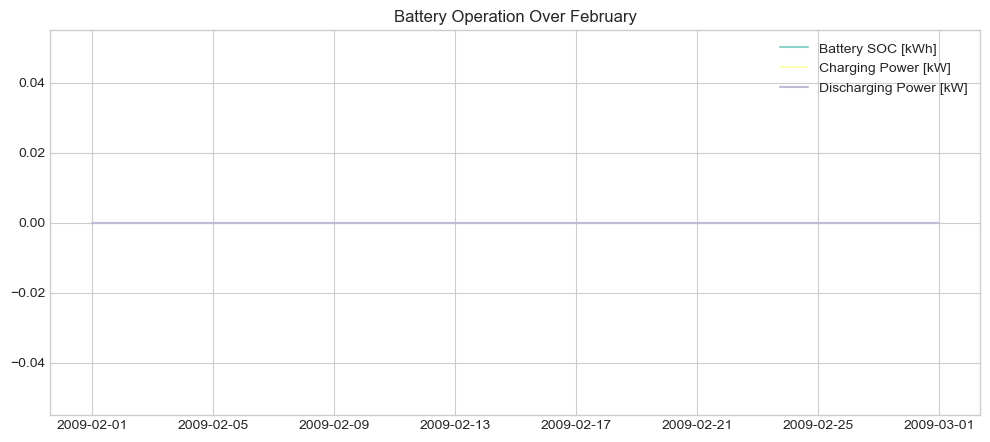

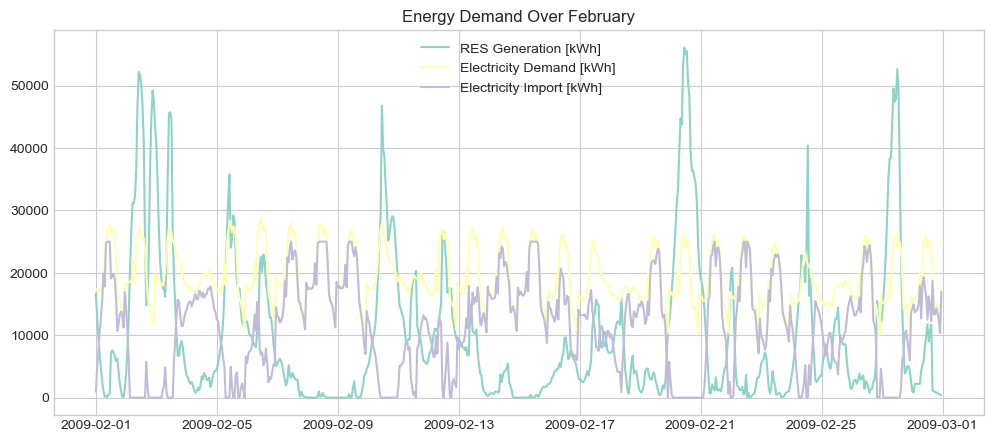

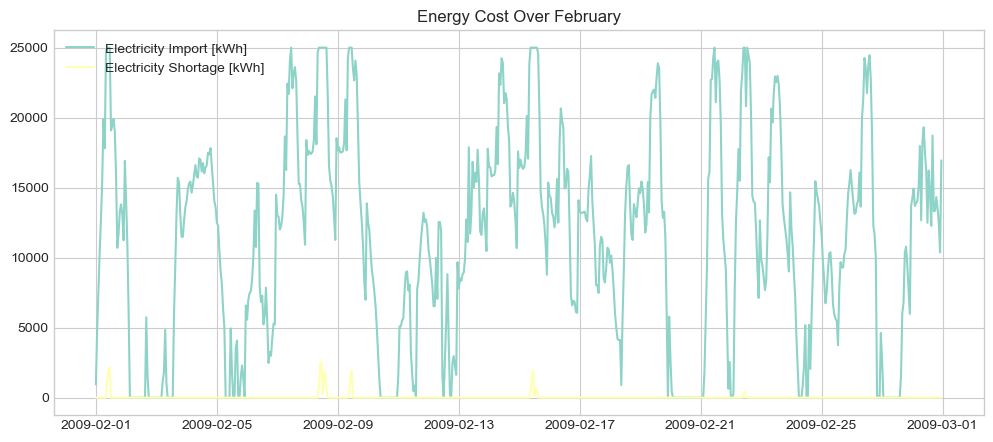

1735431.6658609996
15326.923608132332 381825.4590098908 0.0 0.0 34052.08603471234 5154.247168756061 114827.590252771 0.0 0.0 15000.23986300034 1130623.2360041903 38621.88391954669
7506904.183153778
25643.448031511198


In [607]:
plt.figure(figsize=(12,5))
plt.plot(SOC_zone2, label='Battery SOC [kWh]')
plt.plot(Charge_zone2, label='Charging Power [kW]')
plt.plot(Discharge_zone2, label='Discharging Power [kW]')
plt.legend()
plt.title("Battery Operation Over February")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Total_RES_generation, label='RES Generation [kWh]')
plt.plot(el_demand, label='Electricity Demand [kWh]')
plt.plot(Electricity_import, label='Electricity Import [kWh]')
plt.legend()
plt.title("Energy Demand Over February")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.plot(Electricity_import, label='Electricity Import [kWh]')
plt.plot(Electricity_shortage, label='Electricity Shortage [kWh]')
plt.legend()
plt.title("Energy Cost Over February")
plt.grid(True)
plt.show()

#setting up dataframe for Excel
from pandas import DataFrame
mm_sc0_system_costs = [Complete_costs, Solar_total_cost_monthly, Wind_total_cost_monthly, Battery_total_cost_monthly, Cables_total_cost_monthly, Import_cost_monthly, Lost_load_cost_monthly, '']
mm_sc0_curtailment = [sum(Overshoot_load), sum(Electricity_shortage), '', '', '', '', '', '']
mm_sc0_import = [sum(Electricity_import), sum(Total_RES_generation), Import_cost_monthly, '', '', '', '', '']

mm_df_part1 = pd.read_excel('output_part1.xlsx')
mm_output_part1 = pd.DataFrame({'System Costs': mm_sc0_system_costs, 'Curtailment': mm_sc0_curtailment, 'Imports': mm_sc0_import})
mm_df_part1 = pd.concat([mm_df_part1, mm_output_part1], ignore_index=True)

with pd.ExcelWriter('output_part1.xlsx', mode = 'a', if_sheet_exists = 'overlay') as writer:
    mm_df_part1.to_excel(writer, sheet_name='Scenarios', index=False)

#checks
print(Complete_costs)
print(Solar_total_capex_cost_monthly, Wind_total_capex_cost_monthly, Battery_zone1_total_capex_cost_monthly, Battery_zone2_total_capex_cost_monthly, Cables_total_capex_cost_monthly, Solar_total_opex_cost_monthly, Wind_total_opex_cost_monthly, Battery_zone1_opex_cost_monthly, Battery_zone2_opex_cost_monthly, Cables_total_opex_cost_monthly, Import_cost_monthly, Lost_load_cost_monthly)
print(sum(Electricity_import))
print(sum(Electricity_shortage))

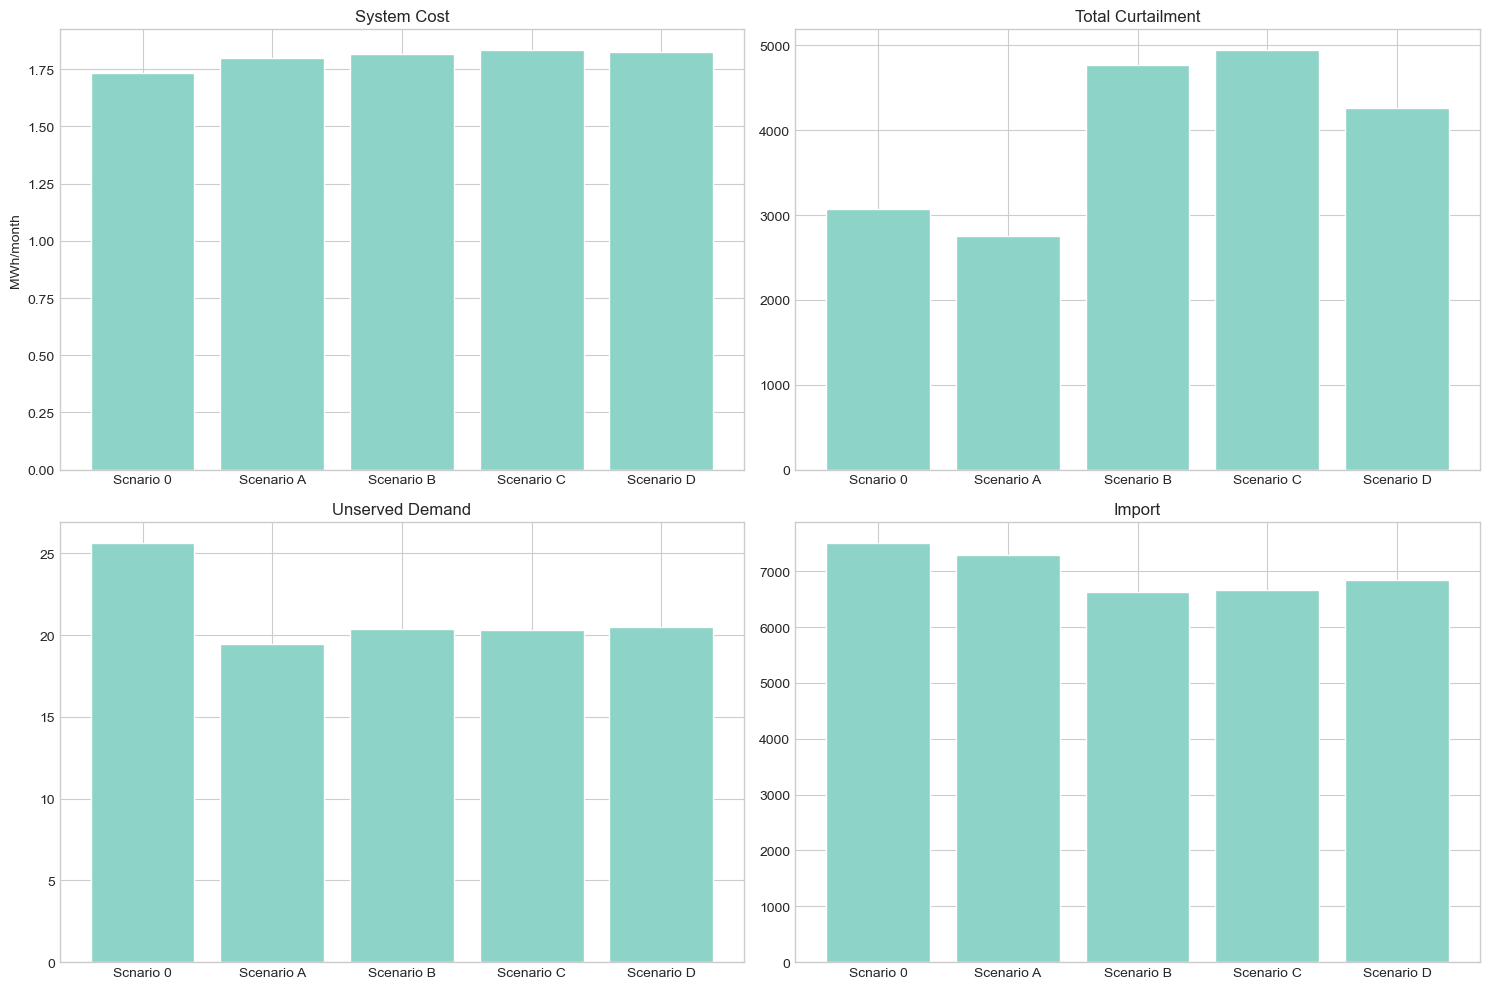

In [624]:
mm_figure_data = pd.read_excel('output_part1.xlsx')

mm_scenarios = np.array(["Scnario 0", "Scenario A", "Scenario B", "Scenario C" , "Scenario D"])

mm_curtailment = np.array([
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[0]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[7]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[14]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[21]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[28]],
]) / 1000

mm_unserved = np.array([
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[1]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[8]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[15]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[22]],
    mm_figure_data['Curtailment'].loc[mm_figure_data.index[29]]
]) / 1000

mm_import = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[0]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[7]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[14]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[21]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[28]]
]) / 1000

mm_domestic = np.array([
    mm_figure_data['Imports'].loc[mm_figure_data.index[1]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[8]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[15]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[22]],
    mm_figure_data['Imports'].loc[mm_figure_data.index[29]]
]) / 1000

mm_total_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[0]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[7]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[14]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[21]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[28]]
]) / 1000000

mm_solar_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[1]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[8]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[15]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[22]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[29]]
]) / 1000000

mm_wind_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[2]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[9]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[16]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[23]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[30]]
]) / 1000000

mm_battery_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[3]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[10]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[17]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[24]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[31]]
]) / 1000000

mm_cables_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[4]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[11]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[18]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[25]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[32]]
]) / 1000000

mm_import_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[5]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[12]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[19]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[26]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[33]]
]) / 1000000

mm_lost_load_costs = np.array([
    mm_figure_data['System Costs'].loc[mm_figure_data.index[6]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[13]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[20]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[27]],
    mm_figure_data['System Costs'].loc[mm_figure_data.index[34]]
]) / 1000000

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

axes[0].bar(mm_scenarios, mm_total_costs)
axes[0].set_title('System Cost')
axes[0].set_ylabel('M€/month')
axes[1].bar(mm_scenarios, mm_curtailment)
axes[1].set_title('Total Curtailment')
axes[1].set_ylabel('MWh')
axes[2].bar(mm_scenarios, mm_unserved)
axes[2].set_title('Unserved Demand')
axes[2].set_ylabel('MWh')
axes[3].bar(mm_scenarios, mm_import)
axes[3].set_title('Import')
axes[3].set_ylabel('MWh')

plt.tight_layout(); plt.show()